# Priprema podataka i izvedeni atributi

U ovoj svesci ćemo izgraditi atribute i sekvence prethodno odigranih mečeva, podeliti podatke hronološki i pripremiti tenzore za modele.

Pravilo koje važi za svaki atribut u ovoj svesci: vrednost za meč `g` sme da zavisi **isključivo** od mečeva odigranih strogo pre `g`. U praksi to znači obavezan `.shift(1)` pre svakog `.rolling(...)`.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from src.config import LAST_TRAIN_SEASON, RANDOM_STATE
from src import data, features, sequences, plotting

np.random.seed(RANDOM_STATE)

## Tabela iz ugla tima

In [2]:
df_games = data.clean_games(data.load_games())
df_games.shape

(24848, 18)

Čišćenje izbacuje pripremne mečeve, duplikate po `GAME_ID` i mečeve bez upisane statistike; preostaje tabela sortirana hronološki, spremna za prevođenje u tabelu iz ugla tima.

In [3]:
df_team_view = features.build_team_view(df_games)
df_team_view.head()

,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,OPPONENT_TEAM_ID,IS_HOME,WON,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB
0,20300006,2003-10-29,2003,1610612737,1610612740,0,0,83.0,0.398,0.737,0.214,18.0,58.0
1,20300024,2003-10-31,2003,1610612737,1610612741,0,0,94.0,0.400,0.714,0.583,22.0,48.0
2,20300029,2003-11-01,2003,1610612737,1610612754,1,0,99.0,0.468,0.677,0.375,23.0,36.0
3,20300042,2003-11-03,2003,1610612737,1610612740,1,1,90.0,0.427,0.652,0.333,20.0,50.0
4,20300060,2003-11-05,2003,1610612737,1610612744,0,0,72.0,0.367,0.500,0.333,19.0,43.0


Svaki meč sada daje dva reda - jedan iz ugla domaćina, jedan iz ugla gosta - sa istim skupom kolona (`PTS`, `FG_PCT`, `AST`, `REB`...) i oznakom `IS_HOME`.

## Pokretne statistike

In [4]:
df_team_view = features.add_rolling_stats(df_team_view)
df_team_view.filter(like="PTS").head()

,PTS,PTS_ROLLING_5,PTS_ROLLING_10
0,83.0,NaN,NaN
1,94.0,83.0,83.0
2,99.0,88.5,88.5
3,90.0,92.0,92.0
4,72.0,91.5,91.5


Svaka pokretna statistika koristi isključivo mečeve odigrane strogo pre trenutnog, zahvaljujući `.shift(1)` pre `.rolling(...)` - prvi meč svakog tima zato nema pokretni prosek (`NaN`).

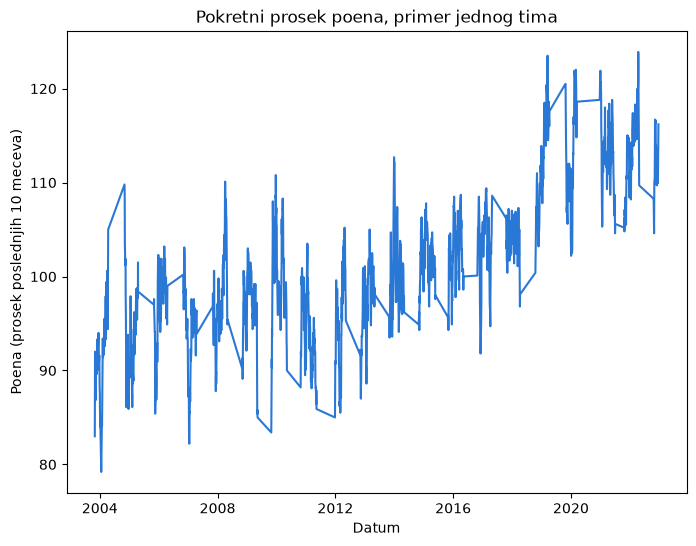

In [5]:
example_team = df_team_view["TEAM_ID"].iloc[0]
df_example = df_team_view[df_team_view["TEAM_ID"] == example_team]

plotting.new_figure(
    "Pokretni prosek poena, primer jednog tima",
    "Datum", "Poena (prosek poslednjih 10 meceva)",
)
plt.plot(df_example["GAME_DATE_EST"], df_example["PTS_ROLLING_10"], color=plotting.COLOR_HOME)
plt.show()

Pokretni prosek poena kroz sezone pokazuje uobičajeno variranje forme tima, bez naglih skokova koji bi ukazivali na grešku u računanju.

## Kalendarski atributi

In [6]:
df_team_view = features.add_calendar_features(df_team_view)
df_team_view[["REST_DAYS", "GAMES_LAST_7_DAYS", "IS_SEASON_START"]].describe()

,REST_DAYS,GAMES_LAST_7_DAYS,IS_SEASON_START
count,49666.000000,48807.000000,49696.000000
mean,4.216547,3.122073,0.012053
std,19.465265,0.776355,0.109125
min,1.000000,1.000000,0.000000
25%,2.000000,3.000000,0.000000
50%,2.000000,3.000000,0.000000
75%,2.000000,4.000000,0.000000
max,288.000000,5.000000,1.000000


`REST_DAYS` meri odmor od prethodnog meča, `GAMES_LAST_7_DAYS` gustinu rasporeda, a `IS_SEASON_START` obeležava prvi meč tima u sezoni - sve tri vrednosti su poznate unapred i ne traže `.shift(1)`.

## Elo rejting

*Funkciju `compute_elo` piše Jana.*

## Međusobni dueli

*Funkciju `add_head_to_head` piše Jana.*

## Stanje na tabeli

Datoteka `ranking.csv` je snimak stanja na tabeli **po danu**, pa spajanje stanja sa datumom strogo pre meča daje legitimne pred-mečevske atribute — procenat pobeda i učinak kod kuće odnosno u gostima.

Kolone `HOME_RECORD` i `ROAD_RECORD` su tekst oblika `28-8` i rastavljaju se na dva broja.

*Funkciju `add_standings_features` piše Jana.*

## Skaliranje

`StandardScaler` se trenira isključivo na trening sezonama (`SEASON <= LAST_TRAIN_SEASON`), pa se istim skalerom transformiše cela tabela. Skaliranje ide pre građenja sekvenci, tako da i sekvence i kontekst ispadnu već skalirani istim skalerom.

In [7]:
df_team_view_train = df_team_view[df_team_view["SEASON"] <= LAST_TRAIN_SEASON]
scaler = sequences.fit_scaler(df_team_view_train)
df_team_view[sequences.SCALED_COLUMNS] = scaler.transform(df_team_view[sequences.SCALED_COLUMNS])

# opisna statistika bas nad trening redovima, da potvrdimo da je scaler
# treniran na njima - ne nad celom tabelom, jer kasnije sezone imaju
# drugaciji stil igre pa im prosek posle skaliranja nece biti nula
df_team_view.loc[df_team_view_train.index, sequences.SCALED_COLUMNS].describe().loc[["mean", "std"]]

,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB,WON,IS_HOME,REST_DAYS,GAMES_LAST_7_DAYS,IS_SEASON_START
mean,-4.645404e-16,-2.981847e-16,2.511029e-16,-2.416865e-16,3.154480e-16,3.868554e-16,0.000000,0.000000,-1.835749e-17,-5.617096e-17,1.189306e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014,1.000014,1.000014e+00,1.000014e+00,1.000014e+00


Trening kolone posle skaliranja imaju prosek blizu nule - tačno očekivano ponašanje `StandardScaler`-a nad podacima na kojima je treniran.

## Građenje sekvenci

In [8]:
home_sequences, away_sequences, context, labels, indices = sequences.build_sequences(
    df_team_view, df_games
)
home_sequences.shape, away_sequences.shape, context.shape, labels.shape

((24830, 10, 8), (24830, 10, 8), (24830, 6), (24830,))

Mečevi bez ijednog odigranog meča pre sebe (prvi meč tima u skupu) se izbacuju - sekvenca bi bila sva od nula i ne bi nosila signal. Kraće sekvence se popunjavaju nulama na početku, tako da poslednji vremenski korak uvek bude najskoriji stvarni meč.

## Hronološka podela

In [9]:
train, validation, test, anomaly = sequences.chronological_split(df_games, indices)
len(train), len(validation), len(test), len(anomaly)

(18092, 2624, 1323, 2314)

Podela je po sezonama iz `config.py`: trening do `LAST_TRAIN_SEASON`, validacija do `LAST_VALIDATION_SEASON`, test je tačno `TEST_SEASON`. Sezone iz `ANOMALY_SEASONS` (kovid) i `UNUSED_SEASONS` (nepotpuna sezona) ne ulaze ni u jedan od tri skupa - anomalne se posebno analiziraju u svesci 05.

In [10]:
dataset_train = sequences.MatchSequenceDataset(
    home_sequences[train], away_sequences[train], context[train], labels[train]
)
len(dataset_train)

18092

`MatchSequenceDataset` pakuje sekvence, kontekst i oznake u torch tenzore tipa `float32`, spreman za `torch.utils.data.DataLoader` u svesci 04.

## Provera na curenje podataka

In [11]:
sequences.assert_no_leakage(df_team_view, "LAST_GAME_DATE", "GAME_DATE_EST")
print("Provera prosla - nijedan atribut ne potice iz buducnosti.")

Provera prosla - nijedan atribut ne potice iz buducnosti.


Provera potvrđuje da je izvorni datum svakog atributa (`LAST_GAME_DATE`, poslednji odigrani meč pre trenutnog) strogo pre datuma meča na koji se atribut odnosi. Ovo je formalni dokaz protiv curenja podataka, na koji se možemo pozvati na odbrani.

## Zaključak

U ovoj svesci smo tabelu mečeva preveli u tabelu iz ugla tima, dodali pokretne statistike i kalendarske atribute, skalirali ih na trening skupu i sastavili sekvence poslednjih `SEQUENCE_LENGTH` mečeva za oba tima. Podela na trening, validaciju i test je hronološka, a sanitarna provera potvrđuje da nijedan atribut ne potiče iz budućnosti.

Elo rejting, međusobni dueli i stanje na tabeli (Janini atributi) će se nadovezati na `df_team_view` pre nego što sekvence i kontekst budu konačan ulaz za modele u sveskama 03 i 04.